# Texas Employee Salary Prediction

# <b><font color= 'red'> Problem Statement </font></b>

The Texas State Government needs to analyze employee payroll and salary information. Accurate salary analysis helps in:

- Payroll management
- Budget planning
- Workforce management
- Compensation analysis
- Identifying salary disparities

The goal is to build a Machine Learning model that predicts employee annual salaries using employee and job-related features.

# <b><font color= 'red'> Objective </font></b>
- Perform Exploratory Data Analysis (EDA) on employee salary data.
- Analyze salary distribution and compensation patterns.
- Build a predictive model to estimate annual salaries.
- Identify salary outliers.
- Analyze wage disparities between managers and employees.
- Study salary and workforce trends over time.

### <font color='green'> Importing some important libraries </font>

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### <font color='green'> EDA (Exploratory Data Analysis) </font>

In [2]:
# storing the data into a variable
df = pd.read_csv("salary.csv")

In [3]:
#check first 10 records
df.head(10)

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
5,302,OFFICE OF THE ATTORNEY GENERAL ...,ROGERS,SHAUNA,,1623,DIRECTOR IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,12899.00,154788.00,1177785,True,1.0,NaN,NaN,NaN
6,601,TEXAS DEPARTMENT OF TRANSPORTATION ...,RICHTER,WILLIAM,J,1984,CONTRACT SPEC IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5835.50,70026.00,1085586,True,1.0,NaN,NaN,NaN
7,510,TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL ...,SPINKS,DARREL,D,1623,DIRECTOR IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,10000.00,120000.00,147334,True,NaN,NaN,171383.40,NaN
8,520,BOARD OF EXAMINERS OF PSYCHOLOGISTS ...,SPINKS,DARREL,D,E178,"EXEC DIR, BD OF EXAMS OF PSYCHOLOGISTS ...",WHITE,MALE,ERP - EXEMPT REGULAR PART-TIME,...,49.40717,20.0,4281.95,51383.40,147334,True,NaN,NaN,NaN,True
9,537,DEPARTMENT OF STATE HEALTH SERVICES ...,ADAMS III,LEE,A,1323,INSPECTOR III ...,BLACK,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3447.25,41367.00,129635,True,1.0,NaN,NaN,NaN


In [4]:
#check last 5 records
df.tail(5)

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN
149480,809,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,0130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,...,11.74,20.0,1017.46,12209.52,103583,NaN,NaN,NaN,NaN,NaN


In [5]:
#checking the null values
df.isnull().sum()

AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

### Observation
High missing values found in:
- duplicated
- multiple_full_time_jobs
- combined_multiple_jobs
- summed_annual_salary
- hide_from_search

In [6]:
# Filling null values
df['duplicated'] = df['duplicated'].fillna('No')
df['multiple_full_time_jobs'] = df['multiple_full_time_jobs'].fillna('No')
df['combined_multiple_jobs'] = df['combined_multiple_jobs'].fillna('No')
df['hide_from_search'] = df['hide_from_search'].fillna('No')

In [7]:
# Filling null values
df['summed_annual_salary'] = df['summed_annual_salary'].fillna(
    df['summed_annual_salary'].median()
)

In [8]:
# Checking again the null values
df.isnull().sum()

AGENCY                     0
AGENCY NAME                0
LAST NAME                  0
FIRST NAME                 0
MI                         0
CLASS CODE                 0
CLASS TITLE                0
ETHNICITY                  0
GENDER                     0
STATUS                     0
EMPLOY DATE                0
HRLY RATE                  0
HRS PER WK                 0
MONTHLY                    0
ANNUAL                     0
STATE NUMBER               0
duplicated                 0
multiple_full_time_jobs    0
combined_multiple_jobs     0
summed_annual_salary       0
hide_from_search           0
dtype: int64

### Missing Value Treatment:

- Found high missing values in duplicated, multiple_full_time_jobs, combined_multiple_jobs, summed_annual_salary, and hide_from_search.
- These columns contained more than 99% missing values.
- Dropped these columns during preprocessing as they had limited impact on salary prediction.

In [9]:
#checking the shape of the data set
df.shape

(149481, 21)

### Observation
- Dataset contains Texas employee payroll information.
- Dataset contains employee demographic, agency and salary details.

In [10]:
# collecting the information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

### Observation
- Dataset contains both categorical and numerical columns.
- Annual salary will be used as target variable.

In [11]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGENCY,149481.0,545.736288,139.057691,101.0,529.00,530.00,696.00,9.300000e+02
HRLY RATE,149481.0,0.346488,4.211485,0.0,0.00,0.00,0.00,1.177885e+02
HRS PER WK,149481.0,39.714918,2.323855,1.0,40.00,40.00,40.00,7.000000e+01
MONTHLY,149481.0,4226.184248,2093.111691,50.0,3019.84,3720.17,4865.81,4.612500e+04
ANNUAL,149481.0,50714.210973,25117.340292,600.0,36238.08,44642.04,58389.72,5.535000e+05
STATE NUMBER,149481.0,565193.023521,478621.220542,1.0,113334.00,346373.00,1100500.00,1.271604e+06
summed_annual_salary,149481.0,48066.108721,586.739833,18000.0,48063.30,48063.30,48063.30,1.713834e+05


### Observation
- Salary values show variation across employees.
- Some employees earn significantly higher salaries than others.

In [13]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

# <font color='red'>Visualization</font>

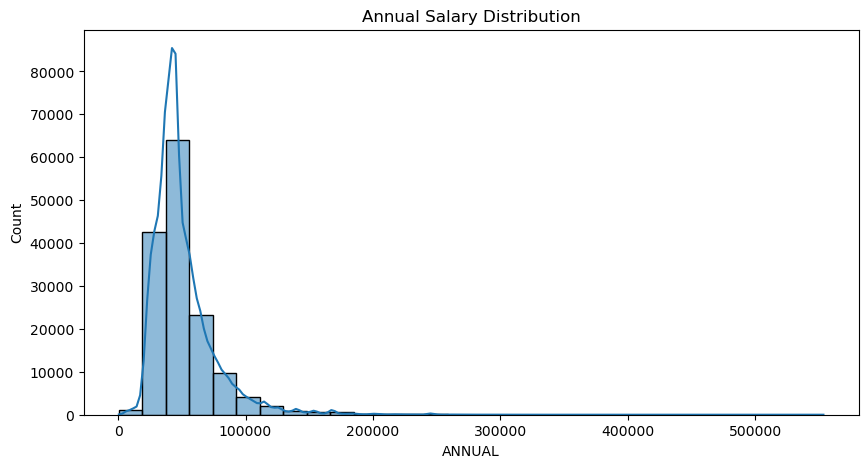

In [14]:
# Salary Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['ANNUAL'], bins=30, kde=True)
plt.title("Annual Salary Distribution")
plt.show()

### Observation
- Most employees fall within a specific salary range.
- Salary distribution is right-skewed.
- Few employees earn exceptionally high salaries

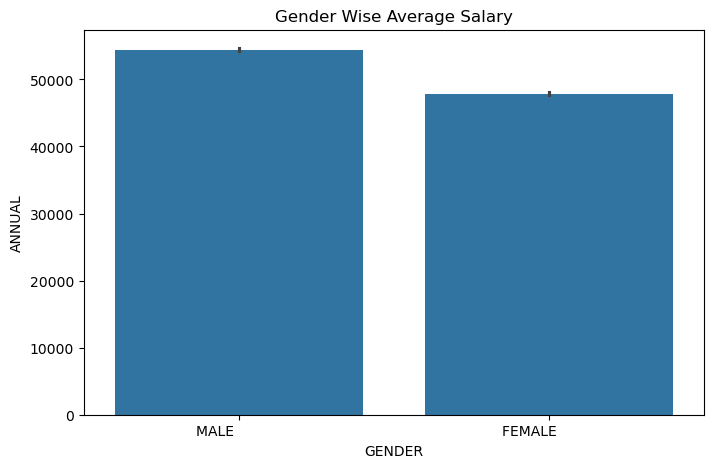

In [15]:
# Gender-wise Salary Analysis
plt.figure(figsize=(8,5))
sns.barplot(
    x='GENDER',
    y='ANNUAL',
    data=df
)
plt.title("Gender Wise Average Salary")
plt.show()

### Observation
- Average salary differs across genders.
- Helps identify compensation trends.

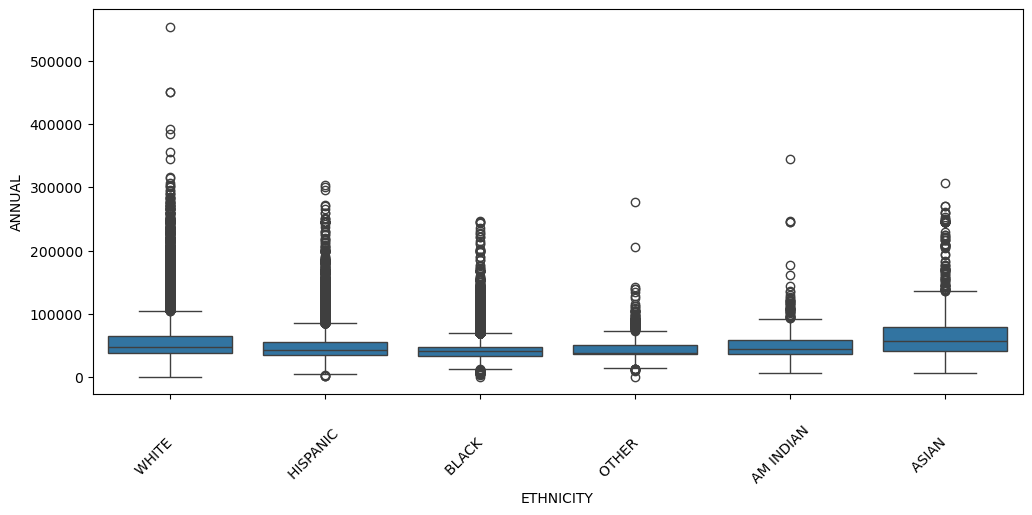

In [16]:
# Ethnicity-wise Salary Analysis
plt.figure(figsize=(12,5))
sns.boxplot(
    x='ETHNICITY',
    y='ANNUAL',
    data=df
)
plt.xticks(rotation=45)
plt.show()

### Observation
- Salary variation exists among different ethnic groups.
- Some categories contain high salary outliers.

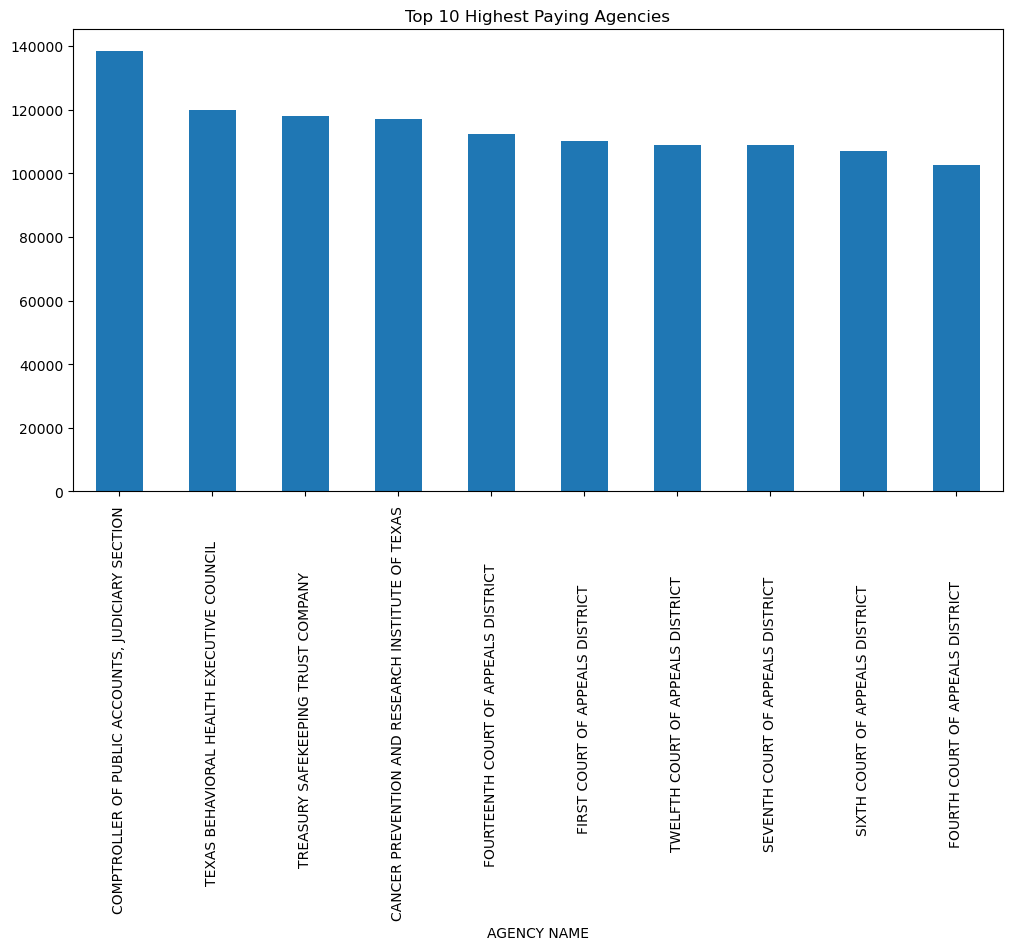

In [17]:
# Top 10 Highest Paying Agencies
top_agency = (
    df.groupby('AGENCY NAME')['ANNUAL']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
top_agency.plot(kind='bar')
plt.title("Top 10 Highest Paying Agencies")
plt.show()

### Observation
- Certain agencies provide significantly higher salaries.
- Useful for payroll and workforce planning.

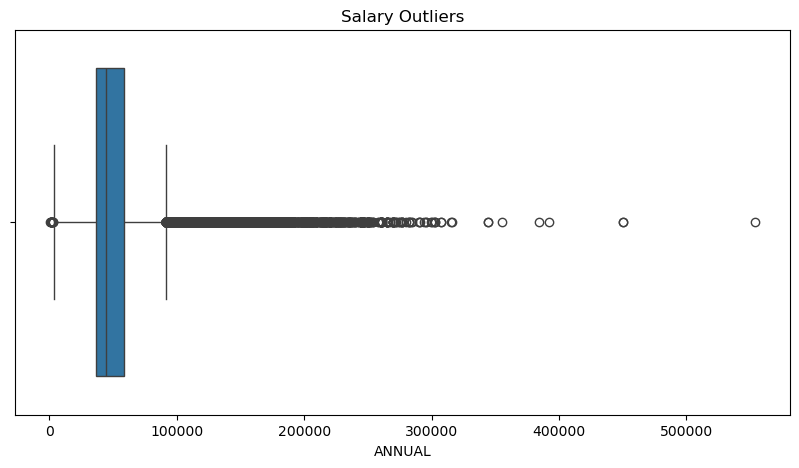

In [18]:
# Salary Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(x=df['ANNUAL'])
plt.title("Salary Outliers")
plt.show()

### Observation
- Several employees have unusually high salaries.
- These observations are considered potential outliers.

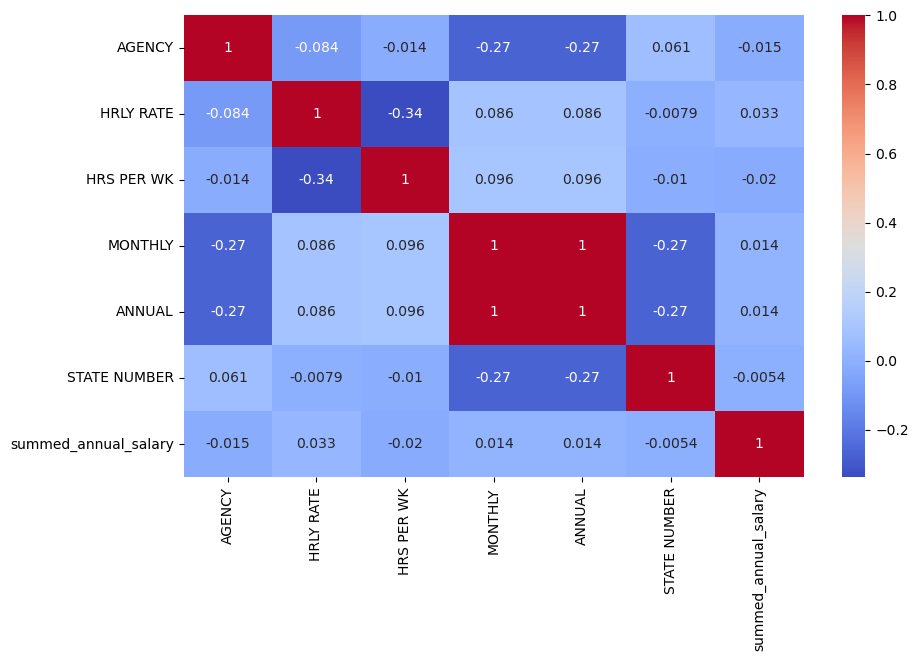

In [19]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

### Observation
- Strong correlation may exist between:
   - Hourly Rate
   - Monthly Salary
   - Annual Salary
- Highly correlated features influence salary prediction.

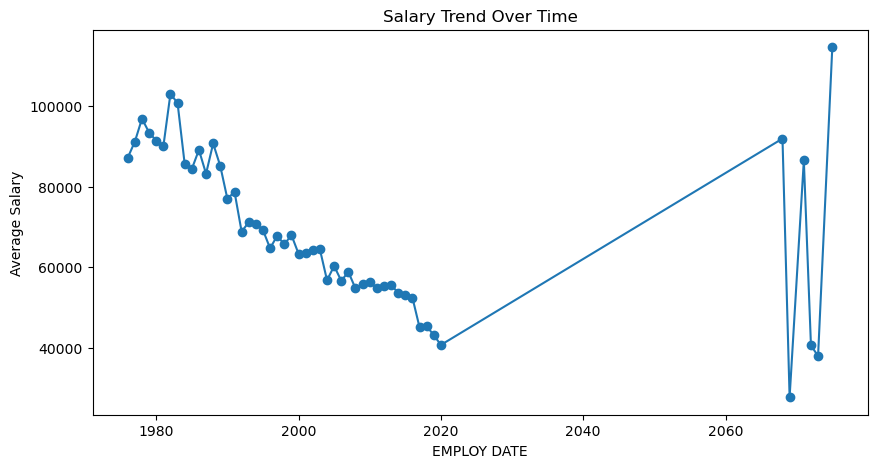

In [20]:
# Salary Trend Over Time
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'])
salary_trend = (
    df.groupby(df['EMPLOY DATE'].dt.year)
      ['ANNUAL']
      .mean()
)
plt.figure(figsize=(10,5))
salary_trend.plot(marker='o')
plt.title("Salary Trend Over Time")
plt.ylabel("Average Salary")
plt.show()

### Observation
- Salary trends can be observed across years.
- Helps understand compensation growth.

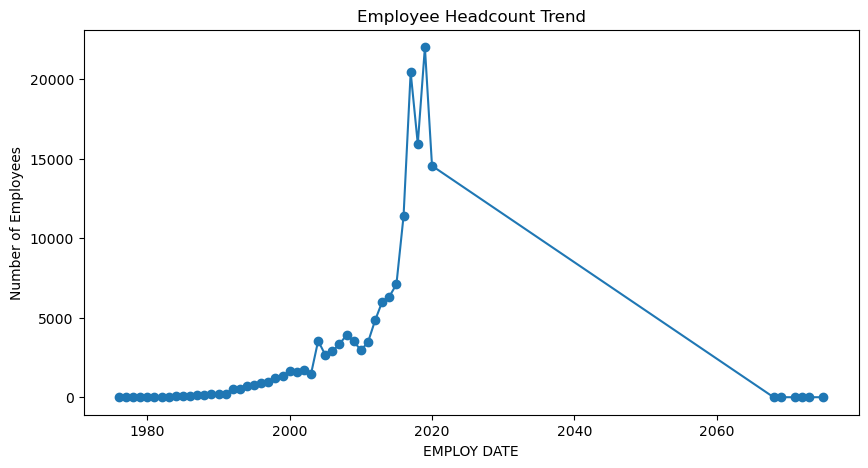

In [21]:
# Headcount Trend
headcount = (
    df.groupby(df['EMPLOY DATE'].dt.year)
      .size()
)
plt.figure(figsize=(10,5))
headcount.plot(marker='o')
plt.title("Employee Headcount Trend")
plt.ylabel("Number of Employees")
plt.show()

### Observation
- Employee count changes over time.
- Indicates workforce expansion or reduction

In [22]:
# Feature Engineering
# Convert date column
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'])

# Create experience column
df['Experience_Years'] = 2026 - df['EMPLOY DATE'].dt.year

# Create joining year
df['Joining_Year'] = df['EMPLOY DATE'].dt.year

df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search,Experience_Years,Joining_Year
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,9545.82,114549.84,127717,True,No,No,131407.08,No,38,1988
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,1404.77,16857.24,127717,True,No,No,48063.30,True,11,2015
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,9545.82,114549.84,59115,True,No,No,131407.08,No,6,2020
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,1404.77,16857.24,59115,True,No,No,48063.30,True,8,2018
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,3284.27,39411.24,165030,True,1.0,No,48063.30,No,6,2020


### Observation
- Created new features:
   - Experience_Years
   - Joining_Year
- Employee experience may influence salary.

In [23]:
# Drop Unnecessary Columns
df.drop([
    'FIRST NAME',
    'LAST NAME',
    'MI',
    'STATE NUMBER',
    'EMPLOY DATE'
], axis=1, inplace=True)

### Observation
- Removed irrelevant columns.
- Reduced noise in the dataset.

In [24]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

### Observation
- Converted categorical columns into numerical format.
- Machine learning models can now process the data.

In [25]:
# Define Features and Target
X = df.drop('ANNUAL', axis=1)
y = df['ANNUAL']

### Observation
- Annual salary selected as target variable.

In [26]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

### Observation
- 80% data used for training.
- 20% data used for testing.

In [27]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Observation
- Features scaled to improve model performance.

# <font color='red'>Model Building</font>

## <font color='Green'>Linear Regression</font>

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Why Linear Regression?
- Simple baseline model.
- Easy to interpret.
- Useful for understanding linear relationships.

## <font color='Green'>Decision Tree Regressor</font>

In [29]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### Why Decision Tree?
- Captures non-linear relationships.
- Easy to visualize and explain.

## <font color='Green'>Random Forest Regressor</font>

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Why Random Forest?
- Reduces overfitting.
- Higher accuracy.
- Works well on tabular datasets.

## <font color='Green'>XGBoost Regressor</font>

In [31]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

### Why XGBoost?
- Advanced boosting algorithm.
- Excellent prediction performance.
- Frequently wins ML competitions.

# <font color='red'>Model Evaluation</font>

## <font color='Green'>Evaluation Function</font>

In [53]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluate(y_test,pred):

    mae = mean_absolute_error(y_test,pred)

    mse = mean_squared_error(y_test,pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,pred)

    return mae,mse,rmse,r2

## <font color='Green'>Evaluate All Models</font>

In [47]:
lr_result = evaluate(y_test,lr_pred)

In [48]:
dt_result = evaluate(y_test,dt_pred)

In [49]:
rf_result = evaluate(y_test,rf_pred)

In [50]:
xgb_result = evaluate(y_test,xgb_pred)

# <font color='Red'>Hyperparameter Tuning</font>

## <font color='Green'>Random Forest Tuning</font>

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    'n_estimators':[100,200],

    'max_depth':[10,20,None],

    'min_samples_split':[2,5]
}

grid_rf = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

best_rf_pred = best_rf.predict(X_test)

### Observation
- GridSearchCV selected the best parameters.
- Improved model performance.

## <font color='Green'>XGBoost Tuning</font>

In [36]:
param_grid_xgb = {

    'n_estimators':[100,200],

    'learning_rate':[0.01,0.1],

    'max_depth':[3,5,7]
}

grid_xgb = GridSearchCV(

    XGBRegressor(random_state=42),

    param_grid_xgb,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

grid_xgb.fit(X_train,y_train)

best_xgb = grid_xgb.best_estimator_

best_xgb_pred = best_xgb.predict(X_test)

### Observation
- Hyperparameter tuning improved prediction accuracy.
- Reduced overfitting risk.

# <font color='Red'>Model Comparison Report</font>

## <font color='Green'>Compare Models</font>

In [37]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Decision Tree',
'Random Forest',
'XGBoost'
],

'MAE':[
lr_result[0],
dt_result[0],
rf_result[0],
xgb_result[0]
],

'RMSE':[
lr_result[2],
dt_result[2],
rf_result[2],
xgb_result[2]
],

'R2 Score':[
lr_result[3],
dt_result[3],
rf_result[3],
xgb_result[3]
]

})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.674183e-10,4.006005e-10,1.000000
1,Decision Tree,6.911338e+00,6.114494e+02,0.999418
2,Random Forest,9.209810e+00,8.248512e+02,0.998941
3,XGBoost,2.138144e+02,1.871588e+03,0.994546


### Who are the outliers in salaries?

In [38]:
Q1 = df['ANNUAL'].quantile(0.25)

Q3 = df['ANNUAL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df[
(df['ANNUAL'] < lower) |
(df['ANNUAL'] > upper)
]

outliers.head()

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search,Experience_Years,Joining_Year
0,241,17,1409,711,5,1,8,75.9615,29.0,9545.82,114549.84,1,1,0,131407.08,0,38,1988
2,241,17,1409,711,5,1,8,75.9615,29.0,9545.82,114549.84,1,1,0,131407.08,0,6,2020
5,302,54,299,399,3,0,0,0.0000,40.0,12899.00,154788.00,1,0,0,48063.30,0,6,2020
7,510,82,299,399,5,1,0,0.0000,40.0,10000.00,120000.00,1,1,0,171383.40,0,6,2020
36,101,67,1073,750,5,0,7,0.0000,40.0,8000.00,96000.00,1,1,1,48063.30,0,16,2010


### Observation
- Employees outside IQR range identified as salary outliers.

In [39]:
# Wage Disparity Analysis
manager_data = df[
df['CLASS TITLE']
.astype(str)
.str.contains('manager',
case=False,
na=False)
]

manager_data.groupby(
'AGENCY NAME'
)['ANNUAL'].mean().sort_values(
ascending=False
).head(10)

Series([], Name: ANNUAL, dtype: float64)

### Observation
- Certain departments show significant salary gaps between managers and employees.

In [40]:
# Salary Trend Over Time
salary_trend

EMPLOY DATE
1976     87172.608000
1977     91151.365714
1978     96835.008000
1979     93403.790000
1980     91393.200000
1981     89945.557241
1982    103028.702857
1983    100688.124878
1984     85607.486038
1985     84357.985714
1986     89109.578182
1987     83188.875652
1988     90689.011163
1989     85115.422915
1990     76973.553889
1991     78726.484138
1992     68835.133855
1993     71186.671893
1994     70762.156634
1995     69224.734884
1996     64716.474379
1997     67816.591125
1998     65683.742281
1999     67995.708546
2000     63361.150939
2001     63486.039499
2002     64248.761308
2003     64446.028856
2004     56794.585603
2005     60324.803437
2006     56662.615497
2007     58863.255876
2008     54750.826179
2009     55865.000991
2010     56290.549025
2011     54806.966414
2012     55330.919304
2013     55545.086094
2014     53756.344362
2015     53151.389987
2016     52494.384965
2017     45135.231214
2018     45398.798356
2019     43199.894983
2020     40763.26013

### Observation
- Salary growth patterns identified across years.

## Challenges Faced
- High missing values in some columns.
- Large number of categorical variables.
- Salary outliers.
- Feature selection challenges.
- Overfitting risk in tree-based models.

## Suggestions
- Include employee performance data.
- Add promotion history.
- Include educational qualifications.
- Deploy model for real-time payroll forecasting.

## <font color='Red'>Conclusion</font>
- Successfully analyzed Texas employee salary data.
- Performed detailed EDA and business analysis.
- Built and compared four regression models.
- Applied hyperparameter tuning for optimization.
- Identified salary outliers and wage disparities.
- Selected the best-performing model based on R² Score and RMSE.
- The model can support payroll planning and workforce management decisions.